# Modelo Predictivo para la Recomendación de Oportunidades Laborales en el Ámbito Gubernamental

Autor: Diana Vásquez- Germám Mahecha
Maestría: Ciencia de datos

Objetivo

Desarrollar un modelo predictivo utilizando técnicas de Machine Learning que permita recomendar oportunidades laborales a partir de la información de aspirantes y vacantes públicas.



##Módulo 1. Carga de librerías

Este módulo prepara el entorno de trabajo para la construcción de la Analytical Base Table (ABT). Se importan las librerías necesarias para la manipulación de datos, visualización y preprocesamiento que serán utilizadas durante las diferentes etapas del proyecto.

In [ ]:
# ============================================================
# MÓDULO 1. CONFIGURACIÓN DEL ENTORNO
# Construcción de la Analytical Base Table (ABT)
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 120)

# Configuración de gráficos
plt.style.use("ggplot")

# Ignorar advertencias
import warnings
warnings.filterwarnings("ignore")

print("✔ Librerías cargadas correctamente.")

✔ Librerías cargadas correctamente.


Este primer módulo tiene como finalidad establecer un entorno de trabajo homogéneo y reproducible, garantizando que todas las etapas posteriores de exploración, transformación e integración de los datos se desarrollen bajo una configuración consistente. La importación de las librerías y la definición de parámetros de visualización facilitan la inspección de los datos y mejoran la legibilidad de los resultados obtenidos durante la construcción de la ABT.

##Módulo 2. Carga y validación inicial de los conjuntos de datos

Cargar los tres conjuntos de datos que conformarán la base analítica del proyecto y realizar una validación inicial de su estructura. En esta etapa se verifica la correcta lectura de los archivos, se normalizan los nombres de las columnas y se inspeccionan las dimensiones y tipos de datos para asegurar la consistencia antes de iniciar el análisis exploratorio y la integración de la información.

###2.1. Cargar los datasets

In [ ]:
import pandas as pd

# ============================================================
# MÓDULO 2. CARGA DE LOS CONJUNTOS DE DATOS
# ============================================================

# Los archivos fueron exportados en formato CSV separado por ';'.
# Se utiliza la codificación UTF-8 con BOM y el motor de Python para
# garantizar una lectura correcta de los campos de texto.

formacion = pd.read_csv(
    "/content/Formacion2.csv",
    encoding="utf-8-sig",
    sep=";",
    quotechar='"',
    doublequote=True,
    engine="python"
)

# --- INICIO DE LA CORRECCIÓN ---
# El archivo Formacion2.csv se cargó incorrectamente creando un MultiIndex.
# Reseteamos el índice para convertir los niveles del MultiIndex en columnas.
# Se añade 'drop=True' para evitar que reset_index() cree una columna 'index' adicional.
formacion = formacion.reset_index(drop=True)

# Renombramos las columnas a sus nombres correctos, inferidos de la descripción del dataset
formacion.columns = [
    "postulante",
    "nivel_educativo",
    "municipio_residencia",
    "departamento_residencia",
    "titulo_academico",
    "area_conocimiento",
    "codigo_nbc", # Anteriormente 'unnamed: 0'
    "nivel_formacion" # Anteriormente 'especializacion profesional'
]
# --- FIN DE LA CORRECCIÓN ---

experiencia = pd.read_csv(
    "/content/Experiencia2.csv",
    encoding="utf-8-sig",
    sep=";",
    quotechar='"',
    doublequote=True,
    engine="python"
)

postulaciones = pd.read_csv(
    "/content/Postulaciones2.csv",
    encoding="utf-8-sig",
    sep=";",
    quotechar='"',
    doublequote=True,
    engine="python",
    on_bad_lines="skip"
)

print("✔ Archivos cargados correctamente.")

✔ Archivos cargados correctamente.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###2.2. Normalizar nombres de columnas

In [ ]:
# Eliminar espacios y convertir nombres de columnas a minúsculas
formacion.columns = formacion.columns.str.strip().str.lower()
experiencia.columns = experiencia.columns.str.strip().str.lower()
postulaciones.columns = postulaciones.columns.str.strip().str.lower()

print("✔ Nombres de columnas normalizados.")

✔ Nombres de columnas normalizados.


###2.3. Verificar dimensiones

In [ ]:
print("Dimensiones de los datasets")

print(f"Formación      : {formacion.shape}")
print(f"Experiencia    : {experiencia.shape}")
print(f"Postulaciones  : {postulaciones.shape}")

Dimensiones de los datasets
Formación      : (100000, 8)
Experiencia    : (100000, 4)
Postulaciones  : (100000, 9)


###2.4. Visualizar las primeras filas

In [ ]:
print("===== Formación =====")
display(formacion.head())

print("===== Experiencia =====")
display(experiencia.head())

print("===== Postulaciones =====")
display(postulaciones.head())

===== Formación =====


,postulante,nivel_educativo,municipio_residencia,departamento_residencia,titulo_academico,area_conocimiento,codigo_nbc,nivel_formacion
0,1098985320,BACHILLER,Cartagena De Indias,Bolívar,Bachiller Academico,NaN,NaN,BACHILLER
1,1098985320,BACHILLER,Cartagena De Indias,Bolívar,Reentrenamiento Vigilancia,NaN,NaN,EDUCACION INFORMAL
2,1098985320,BACHILLER,Cartagena De Indias,Bolívar,Fundamentacion Vigilancia,NaN,NaN,EDUCACION INFORMAL
3,1098984464,BACHILLER,Tierralta,Córdoba,Bachiller Academico,NaN,NaN,BACHILLER
4,1098982296,PROFESIONAL,La Plata,Huila,CONTADURIA PUBLICA,CONTADURIA PUBLICA,"ECONOMIA, ADMINISTRACION, CONTADURIA Y AFINES",PROFESIONAL


===== Experiencia =====


,postulante,experiencia_fecha_ingreso,experiencia_fecha_salida,tipo_experiencia
0,1098982296,2008-01-18,2025-05-08,No aplica
1,1098973645,2011-04-27,2025-06-09,No aplica
2,1098971103,2018-10-06,2025-05-30,No aplica
3,1098970443,2008-05-27,2025-05-08,No aplica
4,1098969490,2016-04-22,2016-12-19,No aplica


===== Postulaciones =====


,postulante,id,empleo,requisito_estudio,requisito_experiencia,requisito_tiempo_experiencia,tipo_prueba,aprobo,calificacion
0,1098985320,228806,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,True,NaN
1,1098984464,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,False,NaN
2,1098982296,228809,BRINDAR APOYO EN LA EJECUCION DE LOS PROCEDIMIENTOS CONFORME A LAS DIRECTRICES IMPARTIDAS POR PARTE DE LOS SUB OFICI...,"Curso específico para el cargo de Distinguido, en las condiciones fijadas por la Escuela de Formación. (artículo 93 ...",Dos (02) años en el cargo de Dragoneante. (artículo 134 decreto 407 de 1994).,24.0,Verificación Requisito Mínimos,True,NaN
3,1098981594,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,False,NaN
4,1098980502,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,True,NaN


Análisis de la estructura de los datasets

1. Dataset Formación

| Variable                  | Observación                                                          |
| ------------------------- | -------------------------------------------------------------------- |
| `postulante`              | Identificador para la integración.                                   |
| `nivel_educativo`         | Nivel máximo reportado por el aspirante.                             |
| `municipio_residencia`    | Variable geográfica.                                                 |
| `departamento_residencia` | Variable geográfica.                                                 |
| `titulo_academico`        | Formación específica registrada.                                     |
| `codigo_nbc`              | Núcleo Básico del Conocimiento. Presenta valores nulos.              |
| `area_conocimiento`       | Área del conocimiento. Presenta valores nulos.                       |
| `nivel_formacion`         | Tipo de formación (Bachiller, Tecnológico, Formación Laboral, etc.). |

Hallazgos
Cada fila representa una formación académica del postulante.
Un postulante puede tener múltiples registros.
Los valores nulos en codigo_nbc y area_conocimiento son esperados para niveles como bachillerato o formación laboral.

Conclusión
Este dataset será la base para construir el perfil académico del postulante.

2. Dataset Experiencia

| Variable                    | Observación                             |
| --------------------------- | --------------------------------------- |
| `postulante`                | Identificador.                          |
| `experiencia_fecha_ingreso` | Fecha de inicio de la experiencia.      |
| `experiencia_fecha_salida`  | Fecha de finalización.                  |
| `tipo_experiencia`          | En la muestra aparece como "No aplica". |

Hallazgos
Existe un registro de experiencia por postulante en la muestra observada.
Las fechas permitirán calcular la duración de la experiencia laboral.
Será necesario convertir ambas columnas al tipo datetime.

Conclusión
Este dataset permitirá construir las variables de experiencia laboral sin necesidad de consolidar múltiples registros, salvo que detectemos postulantes repetidos.   

3. Dataset Postulaciones

| Variable                       | Observación                                |
| ------------------------------ | ------------------------------------------ |
| `postulante`                   | Identificador.                             |
| `id`                           | Identificador de la convocatoria o empleo. |
| `empleo`                       | Descripción textual del cargo.             |
| `requisito_estudio`            | Requisitos académicos.                     |
| `requisito_experiencia`        | Requisitos de experiencia.                 |
| `requisito_tiempo_experiencia` | Tiempo mínimo exigido.                     |
| `tipo_prueba`                  | Etapa del proceso de selección.            |
| `aprobo`                       | Resultado de la prueba.                    |
| `calificacion`                 | Se observa vacía en la muestra.            |


Hallazgos
El resultado de interés es la variable aprobo, que podría utilizarse como variable objetivo.
Las columnas empleo, requisito_estudio y requisito_experiencia contienen texto descriptivo con un alto potencial para análisis mediante PLN.
calificacion parece no estar diligenciada; lo confirmaremos en el análisis de calidad.

Conclusión
Este dataset aporta el contexto de la postulación y el resultado del proceso de selección.

###2.5. Verificar la estructura de cada dataset

In [ ]:
print("===== Formación =====")
formacion.info()

print("\n===== Experiencia =====")
experiencia.info()

print("\n===== Postulaciones =====")
postulaciones.info()

===== Formación =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   postulante               100000 non-null  int64 
 1   nivel_educativo          100000 non-null  object
 2   municipio_residencia     100000 non-null  object
 3   departamento_residencia  100000 non-null  object
 4   titulo_academico         100000 non-null  object
 5   area_conocimiento        20903 non-null   object
 6   codigo_nbc               18979 non-null   object
 7   nivel_formacion          100000 non-null  object
dtypes: int64(1), object(7)
memory usage: 6.1+ MB

===== Experiencia =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   postulante                 1

###2.6. Resumen general de los datasets

In [ ]:
def resumen_dataset(df, nombre):

    resumen = pd.DataFrame({
        "Variable": df.columns,
        "Tipo": df.dtypes.astype(str),
        "No nulos": df.notnull().sum(),
        "Nulos": df.isnull().sum(),
        "% Nulos": round(df.isnull().mean()*100,2)
    })

    print("="*70)
    print(nombre.upper())
    print("="*70)

    display(resumen)

In [ ]:
resumen_dataset(formacion,"Formación")
resumen_dataset(experiencia,"Experiencia")
resumen_dataset(postulaciones,"Postulaciones")

FORMACIÓN


,Variable,Tipo,No nulos,Nulos,% Nulos
postulante,postulante,int64,100000,0,0.00
nivel_educativo,nivel_educativo,object,100000,0,0.00
municipio_residencia,municipio_residencia,object,100000,0,0.00
departamento_residencia,departamento_residencia,object,100000,0,0.00
titulo_academico,titulo_academico,object,100000,0,0.00
area_conocimiento,area_conocimiento,object,20903,79097,79.10
codigo_nbc,codigo_nbc,object,18979,81021,81.02
nivel_formacion,nivel_formacion,object,100000,0,0.00


EXPERIENCIA


,Variable,Tipo,No nulos,Nulos,% Nulos
postulante,postulante,int64,100000,0,0.0
experiencia_fecha_ingreso,experiencia_fecha_ingreso,object,100000,0,0.0
experiencia_fecha_salida,experiencia_fecha_salida,object,100000,0,0.0
tipo_experiencia,tipo_experiencia,object,100000,0,0.0


POSTULACIONES


,Variable,Tipo,No nulos,Nulos,% Nulos
postulante,postulante,int64,100000,0,0.00
id,id,int64,100000,0,0.00
empleo,empleo,object,100000,0,0.00
requisito_estudio,requisito_estudio,object,100000,0,0.00
requisito_experiencia,requisito_experiencia,object,100000,0,0.00
requisito_tiempo_experiencia,requisito_tiempo_experiencia,float64,89734,10266,10.27
tipo_prueba,tipo_prueba,object,100000,0,0.00
aprobo,aprobo,bool,100000,0,0.00
calificacion,calificacion,float64,53577,46423,46.42


##Módulo 3. Análisis de la estructura de los datos

Verificar la cardinalidad de cada conjunto de datos para determinar si cada postulante posee un único registro o múltiples registros. Este análisis permitirá definir la estrategia de construcción de la ABT, identificando los conjuntos de datos que requieren consolidación antes de su integración.

###3.1. Número de registros y postulantes únicos

In [ ]:
# ============================================================
# PASO 3.1. REGISTROS Y POSTULANTES ÚNICOS
# ============================================================

def resumen_postulantes(df, nombre):

    total_registros = len(df)
    postulantes_unicos = df["postulante"].nunique()

    print("="*70)
    print(nombre.upper())
    print("="*70)
    print(f"Total de registros      : {total_registros:,}")
    print(f"Postulantes únicos      : {postulantes_unicos:,}")
    print(f"Registros por postulante: {total_registros/postulantes_unicos:.2f}")
    print()

resumen_postulantes(formacion,"Formación")
resumen_postulantes(experiencia,"Experiencia")
resumen_postulantes(postulaciones,"Postulaciones")

FORMACIÓN
Total de registros      : 100,000
Postulantes únicos      : 29,587
Registros por postulante: 3.38

EXPERIENCIA
Total de registros      : 100,000
Postulantes únicos      : 31,312
Registros por postulante: 3.19

POSTULACIONES
Total de registros      : 100,000
Postulantes únicos      : 43,705
Registros por postulante: 2.29



###3.2. Distribución de registros por postulante

In [ ]:
# ============================================================
# PASO 3.2. REGISTROS POR POSTULANTE
# ============================================================

def registros_por_postulante(df, nombre):

    print("="*70)
    print(nombre.upper())
    print("="*70)

    conteo = df.groupby("postulante").size()

    print(conteo.describe())

    print("\nFrecuencia de registros por postulante")

    display(conteo.value_counts().sort_index())

registros_por_postulante(formacion,"Formación")
registros_por_postulante(experiencia,"Experiencia")
registros_por_postulante(postulaciones,"Postulaciones")

FORMACIÓN
count    29587.000000
mean         3.379863
std          4.110214
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        150.000000
dtype: float64

Frecuencia de registros por postulante


,count
1,9769
2,7437
3,4134
4,2328
5,1346
6,1045
7,801
8,540
9,450
10,347


EXPERIENCIA
count    31312.000000
mean         3.193664
std          3.506855
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        144.000000
dtype: float64

Frecuencia de registros por postulante


,count
1,10936
2,6664
3,4659
4,2983
5,1853
6,1194
7,735
8,529
9,399
10,266


POSTULACIONES
count    43705.000000
mean         2.288068
std          1.516952
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
dtype: float64

Frecuencia de registros por postulante


,count
1,19645
2,7168
3,6560
4,8099
5,876
6,658
7,367
8,159
9,82
10,35


###3.3. Identificar postulantes con más de un registro

In [ ]:
# ============================================================
# PASO 3.3. POSTULANTES CON MÚLTIPLES REGISTROS
# ============================================================

def multiples_registros(df, nombre):

    conteo = df.groupby("postulante").size()

    multiples = conteo[conteo > 1]

    print("="*70)
    print(nombre.upper())
    print("="*70)

    print(f"Postulantes con más de un registro: {len(multiples):,}")

    if len(multiples) > 0:
        display(multiples.head(10))

multiples_registros(formacion,"Formación")
multiples_registros(experiencia,"Experiencia")
multiples_registros(postulaciones,"Postulaciones")

FORMACIÓN
Postulantes con más de un registro: 19,818


,0
postulante,
897049033,10
897049935,3
897050368,2
897050577,3
897052621,2
897052767,2
897055673,2
897057018,10
897058329,2


EXPERIENCIA
Postulantes con más de un registro: 20,376


,0
postulante,
862709716,8
862719799,6
862721761,2
862722096,3
862740828,4
862746697,5
862754665,3
862758020,2
862764555,5


POSTULACIONES
Postulantes con más de un registro: 24,060


,0
postulante,
858542781,2
858543339,3
858544892,2
858545555,2
858546357,3
858551791,2
858555038,2
858555836,4
858558776,5


###3.4. Análisis de intersección entre los datasets

####3.4.1. Obtener los postulantes únicos

In [ ]:
# ============================================================
# PASO 3.4.1. POSTULANTES ÚNICOS POR DATASET
# ============================================================

post_formacion = set(formacion["postulante"].unique())
post_experiencia = set(experiencia["postulante"].unique())
post_postulaciones = set(postulaciones["postulante"].unique())

print(f"Postulantes Formación     : {len(post_formacion):,}")
print(f"Postulantes Experiencia   : {len(post_experiencia):,}")
print(f"Postulantes Postulaciones : {len(post_postulaciones):,}")

Postulantes Formación     : 29,587
Postulantes Experiencia   : 31,312
Postulantes Postulaciones : 43,705


####3.4.2. Intersección entre pares de datasets

In [ ]:
post_formacion = set(formacion["postulante"].unique())
post_experiencia = set(experiencia["postulante"].unique())
post_postulaciones = set(postulaciones["postulante"].unique())

# ============================================================
# PASO 3.4.2. INTERSECCIÓN ENTRE DATASETS
# ============================================================

print("Formación ∩ Experiencia      :", len(post_formacion & post_experiencia))
print("Formación ∩ Postulaciones    :", len(post_formacion & post_postulaciones))
print("Experiencia ∩ Postulaciones  :", len(post_experiencia & post_postulaciones))

Formación ∩ Experiencia      : 20293
Formación ∩ Postulaciones    : 29587
Experiencia ∩ Postulaciones  : 31312


####3.4.3. Intersección de los tres datasets

In [ ]:
# ============================================================
# PASO 3.4.3. POSTULANTES COMUNES A LOS TRES DATASETS
# ============================================================

post_comunes = (
    post_formacion &
    post_experiencia &
    post_postulaciones
)

print(f"Postulantes presentes en los tres datasets: {len(post_comunes):,}")

Postulantes presentes en los tres datasets: 20,293


####3.4.4. Postulantes exclusivos

In [ ]:
# ============================================================
# PASO 3.4.4. POSTULANTES EXCLUSIVOS
# ============================================================

solo_formacion = post_formacion - (post_experiencia | post_postulaciones)
solo_experiencia = post_experiencia - (post_formacion | post_postulaciones)
solo_postulaciones = post_postulaciones - (post_formacion | post_experiencia)

print(f"Solo Formación     : {len(solo_formacion):,}")
print(f"Solo Experiencia   : {len(solo_experiencia):,}")
print(f"Solo Postulaciones : {len(solo_postulaciones):,}")

Solo Formación     : 0
Solo Experiencia   : 0
Solo Postulaciones : 3,099


####3.4.5. Resumen de integración

In [ ]:
# ============================================================
# PASO 3.4.5. RESUMEN DE INTEGRACIÓN
# ============================================================

resumen = pd.DataFrame({
    "Dataset": ["Formación", "Experiencia", "Postulaciones"],
    "Postulantes únicos": [
        len(post_formacion),
        len(post_experiencia),
        len(post_postulaciones)
    ]
})

display(resumen)

print("\nPostulantes comunes a los tres datasets:", len(post_comunes))

,Dataset,Postulantes únicos
0,Formación,29587
1,Experiencia,31312
2,Postulaciones,43705



Postulantes comunes a los tres datasets: 20293


#Módulo 4. Construcción del Perfil Académico

Consolidar la información académica de cada postulante en una única observación, generando variables descriptivas que representen su nivel educativo, diversidad de formación y áreas de conocimiento. Este proceso permitirá obtener un perfil académico estructurado para su integración posterior en la Analytical Base Table (ABT).

## 4.1. Copia del dataset

In [ ]:
# ============================================================
# MÓDULO 4. CONSTRUCCIÓN DEL PERFIL ACADÉMICO
# PASO 4.1. COPIA DEL DATASET
# ============================================================

formacion_abt = formacion.copy()

print("Registros:", len(formacion_abt))
print("Postulantes:", formacion_abt["postulante"].nunique())

Registros: 100000
Postulantes: 29587


##4.2. Verificar niveles de formación

In [ ]:
# ============================================================
# PASO 4.2. NIVELES DE FORMACIÓN
# ============================================================

display(
    formacion_abt["nivel_formacion"]
    .value_counts()
    .sort_values(ascending=False)
)

,count
nivel_formacion,
EDUCACION INFORMAL,38297
BACHILLER,21480
PROFESIONAL,13044
TECNICO PROFESIONAL,5051
TECNOLOGICO,4428
EDUCACION BASICA SECUNDARIA,3932
FORMACION ACADEMICA,3483
ESPECIALIZACION PROFESIONAL,2872
EDUCACION BASICA PRIMARIA,2135


##4.3. Construcción dinámica del perfil académico

In [ ]:
# ============================================================
# PASO 4.3. CONSTRUCCIÓN DINÁMICA DEL PERFIL ACADÉMICO
# ============================================================

# ---------- Variables generales por postulante ----------

perfil_general = (
    formacion_abt
    .groupby("postulante")
    .agg(
        nivel_educativo=("nivel_educativo", "first"),
        total_formaciones=("titulo_academico", "count"),
        cantidad_areas=("area_conocimiento", "nunique"),
        cantidad_nbc=("codigo_nbc", "nunique")
    )
)

# ---------- Conteo dinámico por nivel de formación ----------

niveles_formacion = (
    pd.crosstab(
        formacion_abt["postulante"],
        formacion_abt["nivel_formacion"]
    )
)

# Renombrar columnas automáticamente

niveles_formacion.columns = [
    "cant_" + c.lower()
               .replace(" ", "_")
               .replace("-", "_")
               .replace("/", "_")
    for c in niveles_formacion.columns
]

# ---------- Integración ----------

perfil_academico = (
    perfil_general
    .join(niveles_formacion)
    .reset_index()
)

perfil_academico.head()

,postulante,nivel_educativo,total_formaciones,cantidad_areas,cantidad_nbc,cant_bachiller,cant_doctorado,cant_educacion_basica_primaria,cant_educacion_basica_secundaria,cant_educacion_informal,cant_especializacion_profesional,cant_especializacion_tecnica_profesional,cant_especializacion_tecnologica,cant_formacion_academica,cant_formacion_laboral,cant_formacion_penitenciaria,cant_maestria,cant_normalista,cant_postdoctorado,cant_profesional,cant_tecnico_profesional,cant_tecnologico
0,897049033,TECNICO PROFESIONAL,10,0,0,0,0,0,1,8,0,0,0,0,1,0,0,0,0,0,0,0
1,897049935,BACHILLER,3,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
2,897050368,PROFESIONAL,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,897050577,ESPECIALIZACION PROFESIONAL,3,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
4,897052063,PROFESIONAL,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


##4.4. Validación del perfil

In [ ]:
print("Registros :", len(perfil_academico))
print("Postulantes:", perfil_academico["postulante"].nunique())

print("\nColumnas generadas:")

display(perfil_academico.columns)

Registros : 29587
Postulantes: 29587

Columnas generadas:


Index(['postulante', 'nivel_educativo', 'total_formaciones', 'cantidad_areas',
       'cantidad_nbc', 'cant_bachiller', 'cant_doctorado',
       'cant_educacion_basica_primaria', 'cant_educacion_basica_secundaria',
       'cant_educacion_informal', 'cant_especializacion_profesional',
       'cant_especializacion_tecnica_profesional',
       'cant_especializacion_tecnologica', 'cant_formacion_academica',
       'cant_formacion_laboral', 'cant_formacion_penitenciaria',
       'cant_maestria', 'cant_normalista', 'cant_postdoctorado',
       'cant_profesional', 'cant_tecnico_profesional', 'cant_tecnologico'],
      dtype='object')

## 4.5. Distribución de las variables académicas

In [ ]:
# ============================================================
# PASO 4.5. DISTRIBUCIÓN DEL PERFIL ACADÉMICO
# ============================================================

# Variables generadas dinámicamente
variables_formacion = [
    col for col in perfil_academico.columns
    if col.startswith("cant_")
]

# Total de registros por nivel de formación
resumen_formacion = (
    perfil_academico[variables_formacion]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

resumen_formacion.columns = [
    "Nivel de formación",
    "Total registros"
]

display(resumen_formacion)

,Nivel de formación,Total registros
0,cant_educacion_informal,38297
1,cant_bachiller,21480
2,cant_profesional,13044
3,cant_tecnico_profesional,5051
4,cant_tecnologico,4428
5,cant_educacion_basica_secundaria,3932
6,cant_formacion_academica,3483
7,cant_especializacion_profesional,2872
8,cant_educacion_basica_primaria,2135
9,cant_formacion_laboral,2111


##4.6. Guardar el perfil academico

In [ ]:
# ============================================================
# PASO 4.6. GUARDAR EL PERFIL ACADÉMICO
# ============================================================

print("Dimensiones del perfil académico:")
print(perfil_academico.shape)

# Guardar para su integración posterior
perfil_academico.to_csv(
    "/content/perfil_academico.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✔ Perfil académico guardado correctamente.")

Dimensiones del perfil académico:
(29587, 22)
✔ Perfil académico guardado correctamente.


##4.7. Verificación final del perfil académico

In [ ]:
# ============================================================
# PASO 4.7. VALIDACIÓN FINAL DEL PERFIL ACADÉMICO
# ============================================================

# Reload perfil_academico from CSV in case the kernel was restarted
import pandas as pd
perfil_academico = pd.read_csv(
    "/content/perfil_academico.csv",
    encoding="utf-8-sig"
)

print("="*70)
print("PERFIL ACADÉMICO")
print("="*70)

print(f"Registros              : {len(perfil_academico):,}")
print(f"Postulantes únicos     : {perfil_academico['postulante'].nunique():,}")
print(f"Variables              : {perfil_academico.shape[1]}")

print("\nValores nulos por variable:\n")

display(
    perfil_academico.isnull()
    .sum()
    .to_frame("Nulos")
)

print("\n✔ Perfil académico listo para integrarse con la ABT.")

PERFIL ACADÉMICO
Registros              : 29,587
Postulantes únicos     : 29,587
Variables              : 22

Valores nulos por variable:



,Nulos
postulante,0
nivel_educativo,0
total_formaciones,0
cantidad_areas,0
cantidad_nbc,0
cant_bachiller,0
cant_doctorado,0
cant_educacion_basica_primaria,0
cant_educacion_basica_secundaria,0
cant_educacion_informal,0



✔ Perfil académico listo para integrarse con la ABT.


In [ ]:
# Revisar el archivo perfil_academico.csv

academico = pd.read_csv("/content/perfil_academico.csv", encoding="utf-8-sig")

print("Dimensiones:", academico.shape)
print("Postulantes únicos:", academico["postulante"].nunique())

display(academico.head())

Dimensiones: (29587, 22)
Postulantes únicos: 29587


,postulante,nivel_educativo,total_formaciones,cantidad_areas,cantidad_nbc,cant_bachiller,cant_doctorado,cant_educacion_basica_primaria,cant_educacion_basica_secundaria,cant_educacion_informal,cant_especializacion_profesional,cant_especializacion_tecnica_profesional,cant_especializacion_tecnologica,cant_formacion_academica,cant_formacion_laboral,cant_formacion_penitenciaria,cant_maestria,cant_normalista,cant_postdoctorado,cant_profesional,cant_tecnico_profesional,cant_tecnologico
0,897049033,TECNICO PROFESIONAL,10,0,0,0,0,0,1,8,0,0,0,0,1,0,0,0,0,0,0,0
1,897049935,BACHILLER,3,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
2,897050368,PROFESIONAL,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,897050577,ESPECIALIZACION PROFESIONAL,3,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
4,897052063,PROFESIONAL,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
print("Registros del DataFrame en memoria:")
print(perfil_academico.shape)

print("\nPostulantes únicos:")
print(perfil_academico["postulante"].nunique())

Registros del DataFrame en memoria:
(29587, 22)

Postulantes únicos:
29587


In [ ]:
print(formacion.shape)
print(formacion["postulante"].nunique())

(100000, 8)
29587


#Módulo 5: Construcción del Perfil de Experiencia

##5.1. Copia del dataset

In [ ]:
# ============================================================
# MÓDULO 5. CONSTRUCCIÓN DEL PERFIL DE EXPERIENCIA
# PASO 5.1. COPIA DEL DATASET
# ============================================================

experiencia_abt = experiencia.copy()

print("Registros :", len(experiencia_abt))
print("Postulantes :", experiencia_abt["postulante"].nunique())

Registros : 100000
Postulantes : 31312


5.2. Conversión de fechas

In [ ]:
# ============================================================
# PASO 5.2. CONVERSIÓN DE FECHAS
# ============================================================

experiencia_abt["experiencia_fecha_ingreso"] = pd.to_datetime(
    experiencia_abt["experiencia_fecha_ingreso"],
    errors="coerce"
)

experiencia_abt["experiencia_fecha_salida"] = pd.to_datetime(
    experiencia_abt["experiencia_fecha_salida"],
    errors="coerce"
)

print(experiencia_abt.dtypes)

postulante                            int64
experiencia_fecha_ingreso    datetime64[ns]
experiencia_fecha_salida     datetime64[ns]
tipo_experiencia                     object
dtype: object


##5.3. Validación de fechas

In [ ]:
# ============================================================
# PASO 5.3. VALIDACIÓN DE FECHAS
# ============================================================

print("Fechas de ingreso nulas:",
      experiencia_abt["experiencia_fecha_ingreso"].isna().sum())

print("Fechas de salida nulas:",
      experiencia_abt["experiencia_fecha_salida"].isna().sum())

Fechas de ingreso nulas: 0
Fechas de salida nulas: 0


##5.4. Ordenamiento de los periodos laborales

In [ ]:
# ============================================================
# PASO 5.4. ORDENAR EXPERIENCIAS
# ============================================================

experiencia_abt = experiencia_abt.sort_values(
    ["postulante",
     "experiencia_fecha_ingreso",
     "experiencia_fecha_salida"]
)

display(experiencia_abt.head())

,postulante,experiencia_fecha_ingreso,experiencia_fecha_salida,tipo_experiencia
99999,862708902,2022-08-01,2024-08-13,No aplica
99994,862709716,2007-11-01,2009-06-30,No aplica
99996,862709716,2009-11-05,2010-05-15,No aplica
99993,862709716,2010-05-19,2010-12-20,No aplica
99997,862709716,2011-06-16,2012-04-01,No aplica


##5.5. Construcción del Perfil de Experiencia Efectiva

Consolidar la trayectoria laboral de cada postulante calculando el tiempo efectivo de experiencia, eliminando periodos traslapados y generando indicadores descriptivos que serán incorporados a la ABT.

In [ ]:
# ============================================================
# PASO 5.5. PERFIL DE EXPERIENCIA EFECTIVA
# ============================================================

def construir_perfil_experiencia(grupo):

    # Ordenar cronológicamente
    grupo = grupo.sort_values("experiencia_fecha_ingreso")

    # Conservar objetos Timestamp
    intervalos = list(
        grupo[
            ["experiencia_fecha_ingreso",
             "experiencia_fecha_salida"]
        ]
        .dropna()
        .itertuples(index=False, name=None)
    )

    # Si no existen intervalos válidos
    if len(intervalos) == 0:

        return pd.Series({

            "total_experiencias": 0,
            "periodos_efectivos": 0,
            "dias_experiencia_efectiva": 0,
            "anios_experiencia_efectiva": 0,
            "fecha_primera_experiencia": pd.NaT,
            "fecha_ultima_experiencia": pd.NaT

        })

    # =====================================================
    # Fusionar periodos traslapados
    # =====================================================

    fusionados = []

    inicio, fin = intervalos[0]

    for nuevo_inicio, nuevo_fin in intervalos[1:]:

        # Ignorar registros inconsistentes
        if nuevo_fin < nuevo_inicio:
            continue

        if nuevo_inicio <= fin:

            fin = max(fin, nuevo_fin)

        else:

            fusionados.append((inicio, fin))

            inicio, fin = nuevo_inicio, nuevo_fin

    fusionados.append((inicio, fin))

    # =====================================================
    # Calcular días efectivos
    # =====================================================

    dias = sum(
        (fin - inicio).days + 1
        for inicio, fin in fusionados
    )

    return pd.Series({

        "total_experiencias": len(grupo),

        "periodos_efectivos": len(fusionados),

        "dias_experiencia_efectiva": dias,

        "anios_experiencia_efectiva": round(dias / 365.25, 2),

        "fecha_primera_experiencia": fusionados[0][0],

        "fecha_ultima_experiencia": fusionados[-1][1]

    })


# =====================================================
# Construcción del perfil
# =====================================================

perfil_experiencia = (
    experiencia_abt
    .groupby("postulante")
    .apply(construir_perfil_experiencia)
    .reset_index()
)

display(perfil_experiencia.head())

,postulante,total_experiencias,periodos_efectivos,dias_experiencia_efectiva,anios_experiencia_efectiva,fecha_primera_experiencia,fecha_ultima_experiencia
0,862708902,1,1,744,2.04,2022-08-01,2024-08-13
1,862709716,8,8,4458,12.21,2007-11-01,2024-02-09
2,862715008,1,1,2886,7.90,2016-09-19,2024-08-13
3,862715115,1,1,2539,6.95,2017-09-01,2024-08-13
4,862717306,1,1,502,1.37,2022-08-01,2023-12-15


##5.6. Variables de duración de cada experiencia

In [ ]:
# ============================================================
# PASO 5.6. DURACIÓN DE CADA EXPERIENCIA
# ============================================================

experiencia_abt["dias_experiencia"] = (
    experiencia_abt["experiencia_fecha_salida"] -
    experiencia_abt["experiencia_fecha_ingreso"]
).dt.days + 1

experiencia_abt["anios_experiencia"] = (
    experiencia_abt["dias_experiencia"] / 365.25
).round(2)

display(experiencia_abt.head())

,postulante,experiencia_fecha_ingreso,experiencia_fecha_salida,tipo_experiencia,dias_experiencia,anios_experiencia
99999,862708902,2022-08-01,2024-08-13,No aplica,744,2.04
99994,862709716,2007-11-01,2009-06-30,No aplica,608,1.66
99996,862709716,2009-11-05,2010-05-15,No aplica,192,0.53
99993,862709716,2010-05-19,2010-12-20,No aplica,216,0.59
99997,862709716,2011-06-16,2012-04-01,No aplica,291,0.80


##5.7. Estadísticos de la experiencia

In [ ]:
# ============================================================
# PASO 5.7. ESTADÍSTICAS DE EXPERIENCIA
# ============================================================

estadisticas = (
    experiencia_abt
    .groupby("postulante")
    .agg(
        experiencia_promedio=("dias_experiencia","mean"),
        experiencia_maxima=("dias_experiencia","max"),
        experiencia_minima=("dias_experiencia","min")
    )
    .round(0)
    .reset_index()
)

display(estadisticas.head())

,postulante,experiencia_promedio,experiencia_maxima,experiencia_minima
0,862708902,744.0,744,744
1,862709716,557.0,1902,100
2,862715008,2886.0,2886,2886
3,862715115,2539.0,2539,2539
4,862717306,502.0,502,502


##5.8. Antigüedad laboral

In [ ]:
# ============================================================
# PASO 5.8. ANTIGÜEDAD LABORAL
# ============================================================

perfil_experiencia["antiguedad_laboral_dias"] = (
    perfil_experiencia["fecha_ultima_experiencia"] -
    perfil_experiencia["fecha_primera_experiencia"]
).dt.days + 1

perfil_experiencia["antiguedad_laboral_anios"] = (
    perfil_experiencia["antiguedad_laboral_dias"] / 365.25
).round(2)

##5.9. Densidad laboral

In [ ]:
# ============================================================
# PASO 5.9. DENSIDAD LABORAL
# ============================================================

perfil_experiencia["densidad_laboral"] = (
    perfil_experiencia["dias_experiencia_efectiva"] /
    perfil_experiencia["antiguedad_laboral_dias"]
).round(3)

perfil_experiencia["densidad_laboral"] = (
    perfil_experiencia["densidad_laboral"]
    .clip(upper=1)
)

Interpretación:

Cercano a 1 → trayectoria continua.
Cercano a 0 → largos períodos sin experiencia registrada.

##5.10. Integración del perfil

In [ ]:
# ============================================================
# PASO 5.10. INTEGRACIÓN DEL PERFIL
# ============================================================

perfil_experiencia = perfil_experiencia.merge(
    estadisticas,
    on="postulante",
    how="left"
)

perfil_experiencia.rename(columns={
    "experiencia_promedio":"duracion_promedio_experiencia",
    "experiencia_maxima":"duracion_maxima_experiencia",
    "experiencia_minima":"duracion_minima_experiencia"
}, inplace=True)

display(perfil_experiencia.head())

,postulante,total_experiencias,periodos_efectivos,dias_experiencia_efectiva,anios_experiencia_efectiva,fecha_primera_experiencia,fecha_ultima_experiencia,antiguedad_laboral_dias,antiguedad_laboral_anios,densidad_laboral,duracion_promedio_experiencia,duracion_maxima_experiencia,duracion_minima_experiencia
0,862708902,1,1,744,2.04,2022-08-01,2024-08-13,744,2.04,1.00,744.0,744,744
1,862709716,8,8,4458,12.21,2007-11-01,2024-02-09,5945,16.28,0.75,557.0,1902,100
2,862715008,1,1,2886,7.90,2016-09-19,2024-08-13,2886,7.90,1.00,2886.0,2886,2886
3,862715115,1,1,2539,6.95,2017-09-01,2024-08-13,2539,6.95,1.00,2539.0,2539,2539
4,862717306,1,1,502,1.37,2022-08-01,2023-12-15,502,1.37,1.00,502.0,502,502


##5.11. Validación final

In [ ]:
# ============================================================
# PASO 5.11. VALIDACIÓN FINAL
# ============================================================

print("="*70)
print("PERFIL DE EXPERIENCIA")
print("="*70)

print("Registros :", len(perfil_experiencia))
print("Postulantes :", perfil_experiencia["postulante"].nunique())
print("Variables :", perfil_experiencia.shape[1])

print("\nValores nulos")

display(
    perfil_experiencia.isnull()
    .sum()
    .to_frame("Nulos")
)

PERFIL DE EXPERIENCIA
Registros : 31312
Postulantes : 31312
Variables : 13

Valores nulos


,Nulos
postulante,0
total_experiencias,0
periodos_efectivos,0
dias_experiencia_efectiva,0
anios_experiencia_efectiva,0
fecha_primera_experiencia,0
fecha_ultima_experiencia,0
antiguedad_laboral_dias,0
antiguedad_laboral_anios,0
densidad_laboral,0


5.12. Estadísticos descriptivos

In [ ]:
# ============================================================
# PASO 5.12. ESTADÍSTICAS DEL PERFIL DE EXPERIENCIA
# ============================================================

perfil_experiencia.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
postulante,31312.0,915815472.995689,862708902.0,884151055.25,909141617.5,932502663.75,1098982296.0,42055207.583724
total_experiencias,31312.0,3.193664,1.0,1.0,2.0,4.0,144.0,3.506855
periodos_efectivos,31312.0,2.771972,1.0,1.0,2.0,3.0,54.0,2.688826
dias_experiencia_efectiva,31312.0,2216.441396,1.0,645.0,1462.0,3160.0,16378.0,2138.973928
anios_experiencia_efectiva,31312.0,6.06827,0.0,1.77,4.0,8.65,44.84,5.856251
fecha_primera_experiencia,31312,2016-11-13 07:59:42.524271872,1979-01-01 00:00:00,2013-06-04 00:00:00,2018-12-10 00:00:00,2022-03-21 00:00:00,2026-03-30 00:00:00,NaN
fecha_ultima_experiencia,31312,2024-03-24 03:50:38.017373440,1991-05-15 00:00:00,2024-02-26 00:00:00,2024-08-30 00:00:00,2024-12-08 00:00:00,2026-06-11 00:00:00,NaN
antiguedad_laboral_dias,31312.0,2688.827031,1.0,793.0,1924.0,3903.25,16777.0,2470.293725
antiguedad_laboral_anios,31312.0,7.361562,0.0,2.17,5.27,10.69,45.93,6.76337
densidad_laboral,31312.0,0.859035,0.015,0.774,0.974,1.0,1.0,0.203035


##5.13. Guardar el perfil

In [ ]:
# ============================================================
# PASO 5.13. GUARDAR PERFIL DE EXPERIENCIA
# ============================================================

perfil_experiencia.to_csv(
    "/content/perfil_experiencia.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensiones del perfil de experiencia:")
print(perfil_experiencia.shape)

print("✔ Perfil de experiencia guardado correctamente.")

Dimensiones del perfil de experiencia:
(31312, 13)
✔ Perfil de experiencia guardado correctamente.


Este módulo incorpora un aspecto diferenciador respecto a una consolidación tradicional: el cálculo de la experiencia laboral efectiva. En lugar de sumar de forma directa la duración de cada registro, se implementó un algoritmo que identifica y fusiona periodos laborales traslapados, evitando la doble contabilización del tiempo trabajado. Esta estrategia genera una medida más precisa de la experiencia acumulada y mejora la calidad de las variables utilizadas para el entrenamiento del modelo predictivo.

#MÓDULO 6. PERFIL DEPARTICIPACION Y DESEMPEÑO EN LOS PROCESOS DE SELECCION

Consolidar el historial de postulaciones de cada aspirante, generando variables que describan su comportamiento en los procesos de selección y sus resultados, obteniendo un único registro por postulante para su integración posterior en la ABT.

Variables que construiremos

Las variables se pueden organizar en cuatro dimensiones.

| Dimensión     | Variables                                                       |
| ------------- | --------------------------------------------------------------- |
| Actividad     | total_postulaciones                                             |
| Participación | total_pruebas_presentadas, tipos_prueba                         |
| Desempeño     | pruebas_aprobadas, porcentaje_aprobacion                        |
| Resultados    | promedio_calificacion, maxima_calificacion, minima_calificacion |


##6.1. Copia del dataset

In [ ]:
# ============================================================
# MÓDULO 6. PERFIL DE POSTULACIONES
# PASO 6.1. COPIA DEL DATASET
# ============================================================

postulaciones_abt = postulaciones.copy()

print("Registros :", len(postulaciones_abt))
print("Postulantes :", postulaciones_abt["postulante"].nunique())

Registros : 100000
Postulantes : 43705


##6.2. Exploración inicial

In [ ]:
# ============================================================
# PASO 6.2. EXPLORACIÓN DE VARIABLES
# ============================================================

display(postulaciones_abt.head())

print("\nTipos de datos\n")

print(postulaciones_abt.dtypes)

,postulante,id,empleo,requisito_estudio,requisito_experiencia,requisito_tiempo_experiencia,tipo_prueba,aprobo,calificacion
0,1098985320,228806,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,True,NaN
1,1098984464,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,False,NaN
2,1098982296,228809,BRINDAR APOYO EN LA EJECUCION DE LOS PROCEDIMIENTOS CONFORME A LAS DIRECTRICES IMPARTIDAS POR PARTE DE LOS SUB OFICI...,"Curso específico para el cargo de Distinguido, en las condiciones fijadas por la Escuela de Formación. (artículo 93 ...",Dos (02) años en el cargo de Dragoneante. (artículo 134 decreto 407 de 1994).,24.0,Verificación Requisito Mínimos,True,NaN
3,1098981594,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,False,NaN
4,1098980502,228808,"REALIZAR LAS DISPOSICIONES RELACIONADAS CON EL ORDEN, LA SEGURIDAD, DISCIPLINA, AUTORIDAD, CONVIVENCIA, CUSTODIA Y V...",Título de BACHILLERATO.\n\n,NO REQUIERE EXPERIENCIA,NaN,Verificación Requisito Mínimos,True,NaN



Tipos de datos

postulante                        int64
id                                int64
empleo                           object
requisito_estudio                object
requisito_experiencia            object
requisito_tiempo_experiencia    float64
tipo_prueba                      object
aprobo                             bool
calificacion                    float64
dtype: object


##6.3. Revisar las pruebas existentes

In [ ]:
# ============================================================
# PASO 6.3. TIPOS DE PRUEBA
# ============================================================

tipos_prueba = (
    postulaciones_abt["tipo_prueba"]
    .value_counts()
    .reset_index()
)

tipos_prueba.columns = ["Tipo de prueba","Cantidad"]

display(tipos_prueba)

,Tipo de prueba,Cantidad
0,Verificación Requisito Mínimos,46423
1,Competencias Funcionales,18813
2,Competencias Comportamentales,17238
3,Prueba de Integridad,8006
4,Competencias Basicas Y Funcionales,5848
5,Valoracion De Antecedentes,2328
6,Exclusión puntaje mínimo aprobatorio,595
7,Prueba de Competencias Funcionales,553
8,Prueba de Ejecución (Conductor clasificatoria),138
9,Prueba de ejecución (clasificatoria),45


##6.4. Revisar la variable "aprobo"

In [ ]:
# ============================================================
# PASO 6.4. RESULTADO DE LAS PRUEBAS
# ============================================================

display(
    postulaciones_abt["aprobo"]
    .value_counts(dropna=False)
)

,count
aprobo,
True,63130
False,36870


| Resultado |    Cantidad |  Porcentaje |
| --------- | ----------: | ----------: |
| True      |      63.130 | **63,13 %** |
| False     |      36.870 | **36,87 %** |
| **Total** | **100.000** |   **100 %** |


El 63,13 % de los registros corresponde a pruebas o etapas que fueron aprobadas.
El 36,87 % corresponde a pruebas no aprobadas.
No existen valores nulos ni categorías diferentes de True y False, por lo que la variable tiene buena calidad y puede utilizarse directamente para construir indicadores agregados.

##6.5. Analizar las calificaciones

In [ ]:
# ============================================================
# PASO 6.5. CALIFICACIONES
# ============================================================

print(postulaciones_abt["calificacion"].describe())

print("\nValores nulos:")

print(postulaciones_abt["calificacion"].isna().sum())

count    53577.000000
mean        33.507257
std         34.351384
min          0.000000
25%          0.000000
50%         35.710000
75%         65.600000
max        100.000000
Name: calificacion, dtype: float64

Valores nulos:
46423


Esto nos indica que no todas las pruebas generan una calificación numérica.

En los concursos de la CNSC esto es completamente normal:

Algunas etapas únicamente verifican un requisito (por ejemplo, Verificación de Requisitos Mínimos) y su resultado es Aprobó / No aprobó.
Otras etapas (competencias, conocimientos, valoración de antecedentes, etc.) sí generan una calificación.

Por lo tanto, no podemos reemplazar los valores nulos de calificacion por cero, porque significaría que el postulante obtuvo una nota de 0 cuando en realidad esa prueba nunca fue calificable.

Ese es un criterio metodológico importante para dejar documentado en la tesis.

##6.6 Estandarización de tipos de prueba

In [ ]:
# ============================================================
# PASO 6.6. ESTANDARIZACIÓN DE TIPOS DE PRUEBA
# ============================================================

postulaciones_abt["tipo_prueba"] = (
    postulaciones_abt["tipo_prueba"]
    .replace({

        "Prueba de Competencias Funcionales":
            "Competencias Funcionales",

        "Prueba de Integridad":
            "Integridad",

        "Prueba de Valores e Integridad":
            "Integridad",

        "Prueba de Ejecución (Conductor clasificatoria)":
            "Prueba de Ejecución",

        "Prueba de ejecución (clasificatoria)":
            "Prueba de Ejecución",

        "Prueba ejecución (Eliminatoria)":
            "Prueba de Ejecución"

    })
)

display(
    postulaciones_abt["tipo_prueba"]
    .value_counts()
)

,count
tipo_prueba,
Verificación Requisito Mínimos,46423
Competencias Funcionales,19366
Competencias Comportamentales,17238
Integridad,8009
Competencias Basicas Y Funcionales,5848
Valoracion De Antecedentes,2328
Exclusión puntaje mínimo aprobatorio,595
Prueba de Ejecución,193


##6.7. Construcción dinámica de variables por tipo de prueba

In [ ]:
# ============================================================
# PASO 6.7. VARIABLES POR TIPO DE PRUEBA
# ============================================================

# Crear tabla dinámica
pruebas = pd.crosstab(
    postulaciones_abt["postulante"],
    postulaciones_abt["tipo_prueba"]
)

# Renombrar columnas
pruebas.columns = [
    "cant_" +
    c.lower()
     .replace(" ", "_")
     .replace("á","a")
     .replace("é","e")
     .replace("í","i")
     .replace("ó","o")
     .replace("ú","u")
     .replace("(","")
     .replace(")","")
    for c in pruebas.columns
]

pruebas = pruebas.reset_index()

display(pruebas.head())

,postulante,cant_competencias_basicas_y_funcionales,cant_competencias_comportamentales,cant_competencias_funcionales,cant_exclusion_puntaje_minimo_aprobatorio,cant_integridad,cant_prueba_de_ejecucion,cant_valoracion_de_antecedentes,cant_verificacion_requisito_minimos
0,858542580,0,0,0,0,0,0,0,1
1,858542781,1,0,0,0,0,0,0,1
2,858543339,0,1,1,0,0,0,0,1
3,858544892,0,0,1,0,0,0,0,1
4,858545555,1,0,0,0,0,0,0,1


##6.8. Construcción del perfil general

In [ ]:
# ============================================================
# PASO 6.8. CONSTRUCCIÓN DEL PERFIL DE PARTICIPACIÓN Y DESEMPEÑO
# ============================================================

perfil_postulaciones = (
    postulaciones_abt
    .groupby("postulante")
    .agg(
        # Actividad
        total_registros_pruebas=("id", "count"),
        total_empleos_postulados=("id", "nunique"),

        # Desempeño
        pruebas_aprobadas=("aprobo", "sum"),

        # Resultados de pruebas calificadas
        cantidad_pruebas_calificadas=("calificacion", "count"),
        puntaje_promedio=("calificacion", "mean"),
        puntaje_maximo=("calificacion", "max"),
        puntaje_minimo=("calificacion", "min")
    )
    .reset_index()
)

# Redondear el puntaje promedio
perfil_postulaciones["puntaje_promedio"] = (
    perfil_postulaciones["puntaje_promedio"].round(2)
)

display(perfil_postulaciones.head())

,postulante,total_registros_pruebas,total_empleos_postulados,pruebas_aprobadas,cantidad_pruebas_calificadas,puntaje_promedio,puntaje_maximo,puntaje_minimo
0,858542580,1,1,0,0,NaN,NaN,NaN
1,858542781,2,1,1,1,37.87,37.87,37.87
2,858543339,3,1,3,2,86.84,91.86,81.81
3,858544892,2,1,1,1,0.00,0.00,0.00
4,858545555,2,1,1,1,50.00,50.00,50.00


Variable 1. Cantidad de tipos de prueba presentados


In [ ]:
pruebas["cantidad_tipos_prueba"] = (
    pruebas.drop(columns="postulante")
           .gt(0)
           .sum(axis=1)
)

Variable 2. Total de pruebas presentadas

In [ ]:
pruebas["total_pruebas"] = (
    pruebas.drop(columns=["postulante","cantidad_tipos_prueba"])
           .sum(axis=1)
)

##6.9. Variables derivadas

In [ ]:
# ============================================================
# PASO 6.9. VARIABLES DERIVADAS DEL DESEMPEÑO
# ============================================================

# Pruebas no aprobadas
perfil_postulaciones["pruebas_no_aprobadas"] = (
    perfil_postulaciones["total_registros_pruebas"] -
    perfil_postulaciones["pruebas_aprobadas"]
)

# Porcentaje de aprobación
perfil_postulaciones["porcentaje_aprobacion"] = (
    perfil_postulaciones["pruebas_aprobadas"] /
    perfil_postulaciones["total_registros_pruebas"]
).round(3)

# Porcentaje de pruebas calificadas
perfil_postulaciones["porcentaje_pruebas_calificadas"] = (
    perfil_postulaciones["cantidad_pruebas_calificadas"] /
    perfil_postulaciones["total_registros_pruebas"]
).round(3)

display(perfil_postulaciones.head())

,postulante,total_registros_pruebas,total_empleos_postulados,pruebas_aprobadas,cantidad_pruebas_calificadas,puntaje_promedio,puntaje_maximo,puntaje_minimo,pruebas_no_aprobadas,porcentaje_aprobacion,porcentaje_pruebas_calificadas
0,858542580,1,1,0,0,NaN,NaN,NaN,1,0.0,0.000
1,858542781,2,1,1,1,37.87,37.87,37.87,1,0.5,0.500
2,858543339,3,1,3,2,86.84,91.86,81.81,0,1.0,0.667
3,858544892,2,1,1,1,0.00,0.00,0.00,1,0.5,0.500
4,858545555,2,1,1,1,50.00,50.00,50.00,1,0.5,0.500


##6.10. Integración del perfil

In [ ]:
# ============================================================
# PASO 6.10. INTEGRACIÓN DEL PERFIL DE POSTULACIONES
# ============================================================

perfil_postulaciones = perfil_postulaciones.merge(
    pruebas,
    on="postulante",
    how="left"
)

print("Dimensiones del perfil:")
print(perfil_postulaciones.shape)

display(perfil_postulaciones.head())

Dimensiones del perfil:
(43705, 21)


,postulante,total_registros_pruebas,total_empleos_postulados,pruebas_aprobadas,cantidad_pruebas_calificadas,puntaje_promedio,puntaje_maximo,puntaje_minimo,pruebas_no_aprobadas,porcentaje_aprobacion,porcentaje_pruebas_calificadas,cant_competencias_basicas_y_funcionales,cant_competencias_comportamentales,cant_competencias_funcionales,cant_exclusion_puntaje_minimo_aprobatorio,cant_integridad,cant_prueba_de_ejecucion,cant_valoracion_de_antecedentes,cant_verificacion_requisito_minimos,cantidad_tipos_prueba,total_pruebas
0,858542580,1,1,0,0,NaN,NaN,NaN,1,0.0,0.000,0,0,0,0,0,0,0,1,1,1
1,858542781,2,1,1,1,37.87,37.87,37.87,1,0.5,0.500,1,0,0,0,0,0,0,1,2,2
2,858543339,3,1,3,2,86.84,91.86,81.81,0,1.0,0.667,0,1,1,0,0,0,0,1,3,3
3,858544892,2,1,1,1,0.00,0.00,0.00,1,0.5,0.500,0,0,1,0,0,0,0,1,2,2
4,858545555,2,1,1,1,50.00,50.00,50.00,1,0.5,0.500,1,0,0,0,0,0,0,1,2,2


##6.11. Validación del Perfil de Participación y Desempeño

In [ ]:
# ============================================================
# PASO 6.11. VALIDACIÓN DEL PERFIL
# ============================================================

print("="*70)
print("PERFIL DE PARTICIPACIÓN Y DESEMPEÑO")
print("="*70)

print("Registros :", len(perfil_postulaciones))
print("Postulantes :", perfil_postulaciones["postulante"].nunique())
print("Variables :", perfil_postulaciones.shape[1])

print("\nValores nulos")

display(
    perfil_postulaciones
    .isnull()
    .sum()
    .to_frame("Nulos")
)

PERFIL DE PARTICIPACIÓN Y DESEMPEÑO
Registros : 43705
Postulantes : 43705
Variables : 21

Valores nulos


,Nulos
postulante,0
total_registros_pruebas,0
total_empleos_postulados,0
pruebas_aprobadas,0
cantidad_pruebas_calificadas,0
puntaje_promedio,19956
puntaje_maximo,19956
puntaje_minimo,19956
pruebas_no_aprobadas,0
porcentaje_aprobacion,0


##6.12. Estadísticas descriptivas

In [ ]:
# ============================================================
# PASO 6.12. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

display(
    perfil_postulaciones.describe(include="all").T
)

,count,mean,std,min,25%,50%,75%,max
postulante,43705.0,9.247881e+08,5.108551e+07,858542580.0,8.855824e+08,9.145141e+08,9.450526e+08,1.098985e+09
total_registros_pruebas,43705.0,2.288068e+00,1.516952e+00,1.0,1.000000e+00,2.000000e+00,3.000000e+00,1.900000e+01
total_empleos_postulados,43705.0,1.062190e+00,2.891095e-01,1.0,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+00
pruebas_aprobadas,43705.0,1.444457e+00,1.412541e+00,0.0,1.000000e+00,1.000000e+00,3.000000e+00,1.600000e+01
cantidad_pruebas_calificadas,43705.0,1.225878e+00,1.388811e+00,0.0,0.000000e+00,1.000000e+00,2.000000e+00,1.300000e+01
puntaje_promedio,23749.0,3.196468e+01,2.944010e+01,0.0,0.000000e+00,2.153000e+01,6.128000e+01,9.274000e+01
puntaje_maximo,23749.0,4.374843e+01,3.419617e+01,0.0,0.000000e+00,5.555000e+01,7.155000e+01,1.000000e+02
puntaje_minimo,23749.0,2.311000e+01,2.807120e+01,0.0,0.000000e+00,0.000000e+00,5.250000e+01,9.268000e+01
pruebas_no_aprobadas,43705.0,8.436106e-01,6.613959e-01,0.0,0.000000e+00,1.000000e+00,1.000000e+00,6.000000e+00
porcentaje_aprobacion,43705.0,5.564081e-01,3.806592e-01,0.0,3.330000e-01,5.710000e-01,1.000000e+00,1.000000e+00


##6.13. Guardar el perfil

In [ ]:
# ============================================================
# PASO 6.13. GUARDAR PERFIL
# ============================================================

perfil_postulaciones.to_csv(
    "/content/perfil_postulaciones.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensiones del perfil:")
print(perfil_postulaciones.shape)

print("✔ Perfil de participación y desempeño guardado correctamente.")

Dimensiones del perfil:
(43705, 21)
✔ Perfil de participación y desempeño guardado correctamente.


#MÓDULO 7. CONSTRUCCIÓN DE LA ANALYTICAL BASE TABLE (ABT)

Integrar los perfiles Académico, Experiencia y Participación y Desempeño mediante el identificador único del postulante, obteniendo una única tabla analítica que concentre las características relevantes para el entrenamiento y evaluación de los modelos de Machine Learning.

##7.1. Cargar los perfiles consolidados

In [ ]:
# ============================================================
# MÓDULO 7. CONSTRUCCIÓN DE LA ABT
# PASO 7.1. CARGA DE PERFILES CONSOLIDADOS
# ============================================================

perfil_academico = pd.read_csv(
    "/content/perfil_academico.csv",
    encoding="utf-8-sig"
)

perfil_experiencia = pd.read_csv(
    "/content/perfil_experiencia.csv",
    encoding="utf-8-sig"
)

perfil_postulaciones = pd.read_csv(
    "/content/perfil_postulaciones.csv",
    encoding="utf-8-sig"
)

print("✔ Perfiles cargados correctamente.")

✔ Perfiles cargados correctamente.


##7.2. Verificar dimensiones

In [ ]:
# ============================================================
# PASO 7.2. DIMENSIONES DE LOS PERFILES
# ============================================================

print("="*70)
print("PERFILES CONSOLIDADOS")
print("="*70)

print("Académico      :", perfil_academico.shape)
print("Experiencia    :", perfil_experiencia.shape)
print("Postulaciones  :", perfil_postulaciones.shape)

PERFILES CONSOLIDADOS
Académico      : (29587, 22)
Experiencia    : (31312, 13)
Postulaciones  : (43705, 21)


##7.4. Validación de la intersección de los perfiles

In [ ]:
# ============================================================
# PASO 7.4. VALIDACIÓN DE LA INTERSECCIÓN
# ============================================================

academicos = set(perfil_academico["postulante"])
experiencia = set(perfil_experiencia["postulante"])
postulaciones = set(perfil_postulaciones["postulante"])

interseccion = academicos & experiencia & postulaciones

print("="*70)
print("INTERSECCIÓN DE LOS TRES PERFILES")
print("="*70)

print(f"Académico      : {len(academicos):,}")
print(f"Experiencia    : {len(experiencia):,}")
print(f"Postulaciones  : {len(postulaciones):,}")

print("\nPostulantes comunes:", len(interseccion))

INTERSECCIÓN DE LOS TRES PERFILES
Académico      : 29,587
Experiencia    : 31,312
Postulaciones  : 43,705

Postulantes comunes: 20293


##7.5. Construcción de la ABT

In [ ]:
# ============================================================
# PASO 7.5. CONSTRUCCIÓN DE LA ABT
# ============================================================

abt = (
    perfil_academico
    .merge(
        perfil_experiencia,
        on="postulante",
        how="inner"
    )
    .merge(
        perfil_postulaciones,
        on="postulante",
        how="inner"
    )
)

print("="*70)
print("ABT CONSTRUIDA")
print("="*70)

print("Registros :", len(abt))
print("Postulantes únicos :", abt["postulante"].nunique())
print("Variables :", abt.shape[1])

display(abt.head())

ABT CONSTRUIDA
Registros : 20293
Postulantes únicos : 20293
Variables : 54


,postulante,nivel_educativo,total_formaciones,cantidad_areas,cantidad_nbc,cant_bachiller,cant_doctorado,cant_educacion_basica_primaria,cant_educacion_basica_secundaria,cant_educacion_informal,cant_especializacion_profesional,cant_especializacion_tecnica_profesional,cant_especializacion_tecnologica,cant_formacion_academica,cant_formacion_laboral,cant_formacion_penitenciaria,cant_maestria,cant_normalista,cant_postdoctorado,cant_profesional,cant_tecnico_profesional,cant_tecnologico,total_experiencias,periodos_efectivos,dias_experiencia_efectiva,anios_experiencia_efectiva,fecha_primera_experiencia,fecha_ultima_experiencia,antiguedad_laboral_dias,antiguedad_laboral_anios,densidad_laboral,duracion_promedio_experiencia,duracion_maxima_experiencia,duracion_minima_experiencia,total_registros_pruebas,total_empleos_postulados,pruebas_aprobadas,cantidad_pruebas_calificadas,puntaje_promedio,puntaje_maximo,puntaje_minimo,pruebas_no_aprobadas,porcentaje_aprobacion,porcentaje_pruebas_calificadas,cant_competencias_basicas_y_funcionales,cant_competencias_comportamentales,cant_competencias_funcionales,cant_exclusion_puntaje_minimo_aprobatorio,cant_integridad,cant_prueba_de_ejecucion,cant_valoracion_de_antecedentes,cant_verificacion_requisito_minimos,cantidad_tipos_prueba,total_pruebas
0,897049033,TECNICO PROFESIONAL,10,0,0,0,0,0,1,8,0,0,0,0,1,0,0,0,0,0,0,0,5,4,2031,5.56,2017-01-02,2025-12-27,3282,8.99,0.619,461.0,1459,122,1,1,0,0,NaN,NaN,NaN,1,0.000,0.000,0,0,0,0,0,0,0,1,1,1
1,897049935,BACHILLER,3,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,3323,9.10,2015-06-20,2024-07-24,3323,9.10,1.000,3323.0,3323,3323,3,1,1,2,69.15,78.30,60.00,2,0.333,0.667,0,1,1,0,0,0,0,1,3,3
2,897050368,PROFESIONAL,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,2,2119,5.80,2018-08-23,2024-09-18,2219,6.08,0.955,1060.0,1997,122,1,1,0,0,NaN,NaN,NaN,1,0.000,0.000,0,0,0,0,0,0,0,1,1,1
3,897050577,ESPECIALIZACION PROFESIONAL,3,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,4,4,878,2.40,2022-09-05,2026-03-10,1283,3.51,0.684,220.0,488,1,1,1,0,0,NaN,NaN,NaN,1,0.000,0.000,0,0,0,0,0,0,0,1,1,1
4,897052569,BACHILLER,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,764,2.09,2022-08-19,2024-09-20,764,2.09,1.000,764.0,764,764,3,1,1,2,63.13,69.81,56.45,2,0.333,0.667,0,1,1,0,0,0,0,1,3,3


En la ABT aparecen:

puntaje_promedio   NaN
puntaje_maximo     NaN
puntaje_minimo     NaN

Esto no es un error.

Significa que esos postulantes nunca presentaron una prueba que generara calificación, por ejemplo únicamente participaron en la Verificación de Requisitos Mínimos.

Desde el punto de vista metodológico, estos valores faltantes contienen información y no deben eliminarse.

Mi recomendación será:

Mantener esos registros, En la etapa de preprocesamiento del modelo imputar:
puntaje_promedio = 0
puntaje_maximo = 0
puntaje_minimo = 0

Además, conviene crear una variable binaria como tiene_pruebas_calificadas, pero eso lo haremos en la fase de ingeniería de características.

##7.6 Validación de la ABT

In [ ]:
# ============================================================
# PASO 7.6. VALIDACIÓN DE LA ABT
# ============================================================

print("="*70)
print("VALIDACIÓN DE LA ABT")
print("="*70)

print(f"Registros                : {len(abt):,}")
print(f"Postulantes únicos       : {abt['postulante'].nunique():,}")
print(f"Variables                : {abt.shape[1]}")

print("\nDuplicados por postulante:")

duplicados = abt["postulante"].duplicated().sum()

print(duplicados)

print("\nTipos de datos")

display(abt.dtypes.to_frame("Tipo"))

VALIDACIÓN DE LA ABT
Registros                : 20,293
Postulantes únicos       : 20,293
Variables                : 54

Duplicados por postulante:
0

Tipos de datos


,Tipo
postulante,int64
nivel_educativo,object
total_formaciones,int64
cantidad_areas,int64
cantidad_nbc,int64
cant_bachiller,int64
cant_doctorado,int64
cant_educacion_basica_primaria,int64
cant_educacion_basica_secundaria,int64
cant_educacion_informal,int64


##7.7 Análisis de valores nulos

In [ ]:
# ============================================================
# PASO 7.7. ANÁLISIS DE VALORES NULOS
# ============================================================

nulos = pd.DataFrame({
    "Variable": abt.columns,
    "Nulos": abt.isnull().sum(),
    "% Nulos": (abt.isnull().mean()*100).round(2)
})

nulos = nulos.sort_values("% Nulos", ascending=False)

display(nulos)

,Variable,Nulos,% Nulos
puntaje_minimo,puntaje_minimo,8715,42.95
puntaje_maximo,puntaje_maximo,8715,42.95
puntaje_promedio,puntaje_promedio,8715,42.95
total_formaciones,total_formaciones,0,0.00
postulante,postulante,0,0.00
nivel_educativo,nivel_educativo,0,0.00
cant_doctorado,cant_doctorado,0,0.00
cant_educacion_basica_primaria,cant_educacion_basica_primaria,0,0.00
cant_educacion_basica_secundaria,cant_educacion_basica_secundaria,0,0.00
cant_educacion_informal,cant_educacion_informal,0,0.00


##7.8  Estadísticos descriptivos

In [ ]:
# ============================================================
# PASO 7.8. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

display(
    abt.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
postulante,20293.0,NaN,NaN,NaN,936085006.324841,38672282.999738,897049033.0,909739543.0,927527775.0,942170713.0,1098982296.0
nivel_educativo,20293,17,PROFESIONAL,7226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_formaciones,20293.0,NaN,NaN,NaN,4.026857,4.669347,1.0,2.0,3.0,5.0,150.0
cantidad_areas,20293.0,NaN,NaN,NaN,0.775292,0.722117,0.0,0.0,1.0,1.0,5.0
cantidad_nbc,20293.0,NaN,NaN,NaN,0.648844,0.601089,0.0,0.0,1.0,1.0,4.0
cant_bachiller,20293.0,NaN,NaN,NaN,0.638496,0.536009,0.0,0.0,1.0,1.0,8.0
cant_doctorado,20293.0,NaN,NaN,NaN,0.002365,0.049583,0.0,0.0,0.0,0.0,2.0
cant_educacion_basica_primaria,20293.0,NaN,NaN,NaN,0.075445,0.295633,0.0,0.0,0.0,0.0,7.0
cant_educacion_basica_secundaria,20293.0,NaN,NaN,NaN,0.151185,0.37425,0.0,0.0,0.0,0.0,10.0
cant_educacion_informal,20293.0,NaN,NaN,NaN,1.70241,4.108869,0.0,0.0,0.0,2.0,146.0


##7.9 Guardar la ABT

In [ ]:
# ============================================================
# PASO 7.9. GUARDAR LA ABT
# ============================================================

abt.to_csv(
    "/content/ABT_Modelo_Predictivo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensiones finales de la ABT:")
print(abt.shape)

print("✔ ABT guardada correctamente.")

Dimensiones finales de la ABT:
(20293, 54)
✔ ABT guardada correctamente.


Resultados obtenidos
Integración de perfiles

Se integraron los tres perfiles previamente construidos:

| Perfil                    | Postulantes |
| ------------------------- | ----------: |
| Académico                 |      29.587 |
| Experiencia               |      31.312 |
| Participación y desempeño |      43.705 |



La intersección entre los tres conjuntos produjo:

20.293 postulantes comunes

Este conjunto constituye la población definitiva para el entrenamiento del modelo predictivo.

Construcción de la ABT

Después de realizar los cruces mediante la variable postulante, se obtuvo una base analítica con:

20.293 registros
20.293 postulantes únicos
54 variables

Esto garantiza una relación 1 registro = 1 postulante, condición indispensable para los algoritmos supervisados de Machine Learning.

Variables incorporadas

La ABT reúne información proveniente de tres dimensiones.

Perfil académico

22 variables

Incluye información como:

nivel educativo máximo
número total de formaciones
cantidad de áreas de conocimiento
cantidad de NBC
número de títulos por nivel de formación
bachiller
técnico
tecnólogo
profesional
especialización
maestría
doctorado
educación informal
entre otras.
Perfil laboral

13 variables

Incluye indicadores como:

número de experiencias laborales
años efectivos de experiencia
días efectivos trabajados
antigüedad laboral
duración promedio de contratos
duración máxima
duración mínima
densidad laboral
fecha de primera experiencia
fecha de última experiencia
Perfil de participación y desempeño

21 variables

Entre ellas:

número de postulaciones
número de empleos postulados
pruebas aprobadas
pruebas no aprobadas
porcentaje de aprobación
porcentaje de pruebas calificadas
puntaje promedio
puntaje máximo
puntaje mínimo
número de pruebas por tipo
total de pruebas
Validación de la ABT

La validación permitió comprobar que:

✔ No existen postulantes duplicados.

✔ Todas las variables fueron correctamente integradas.

✔ La llave primaria del modelo corresponde al identificador del postulante.

Valores faltantes

Únicamente se identificaron valores faltantes en tres variables:

| Variable         | % nulos |
| ---------------- | ------: |
| puntaje_promedio | 42.95 % |
| puntaje_maximo   | 42.95 % |
| puntaje_minimo   | 42.95 % |

Este comportamiento era esperado, ya que no todos los postulantes alcanzaron pruebas con calificación numérica. En muchos casos únicamente participaron en la etapa de verificación de requisitos mínimos, la cual registra aprobación o rechazo, pero no genera puntaje cuantitativo.

Por tanto, estos valores no corresponden a errores de calidad del dato, sino a la naturaleza del proceso de selección.

**Características de la base final**

La ABT presenta las siguientes características:

20.293 observaciones.
54 variables explicativas.
Información consolidada de formación, experiencia y desempeño.
Un registro por postulante.
Sin registros duplicados.
Lista para las etapas de preprocesamiento, ingeniería de variables, selección de atributos y entrenamiento de modelos predictivos.

#MÓDULO 8. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Realizar un análisis exploratorio sobre la Base Analítica (ABT) consolidada para comprender la estructura, distribución, calidad y comportamiento de las variables que conformarán el modelo predictivo.

##8.1 Cargar la ABT

In [ ]:
# ============================================================
# MÓDULO 8. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# 8.1 CARGAR LA ABT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar la ABT construida
abt = pd.read_csv("/content/ABT_Modelo_Predictivo.csv")

print("="*70)
print("ANALYTICAL BASE TABLE")
print("="*70)

print("Dimensiones:", abt.shape)
print("Postulantes:", abt["postulante"].nunique())

ANALYTICAL BASE TABLE
Dimensiones: (20293, 54)
Postulantes: 20293


##8.2 Información general

Este paso nos permitirá conocer rápidamente la estructura de la base.

In [ ]:
# ============================================================
# 8.2 INFORMACIÓN GENERAL
# ============================================================

print("="*70)
print("INFORMACIÓN GENERAL")
print("="*70)

abt.info()

print("\nMemoria utilizada:")

print(round(abt.memory_usage(deep=True).sum()/1024**2,2),"MB")

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20293 entries, 0 to 20292
Data columns (total 54 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   postulante                                 20293 non-null  int64  
 1   nivel_educativo                            20293 non-null  object 
 2   total_formaciones                          20293 non-null  int64  
 3   cantidad_areas                             20293 non-null  int64  
 4   cantidad_nbc                               20293 non-null  int64  
 5   cant_bachiller                             20293 non-null  int64  
 6   cant_doctorado                             20293 non-null  int64  
 7   cant_educacion_basica_primaria             20293 non-null  int64  
 8   cant_educacion_basica_secundaria           20293 non-null  int64  
 9   cant_educacion_informal                    20293 non-null  int64  
 10  ca

Resultado:

20.293 postulantes
54 variables
42 enteras
9 decimales
3 categóricas
11.38 MB

Interpretación

La ABT posee un tamaño adecuado para el entrenamiento de modelos de Machine Learning. La mayor parte de las variables son numéricas, lo que facilita su utilización en algoritmos supervisados sin requerir transformaciones complejas.

##8.3 Tipos de variables

In [ ]:
# ============================================================
# 8.3 TIPOS DE VARIABLES
# ============================================================

tipos = abt.dtypes.value_counts().reset_index()

tipos.columns=["Tipo","Cantidad"]

display(tipos)

,Tipo,Cantidad
0,int64,42
1,float64,9
2,object,3


Predominan las variables cuantitativas (94.4%), mientras que únicamente tres corresponden a variables categóricas, las cuales posteriormente serán codificadas mediante técnicas de transformación para su incorporación en los modelos predictivos.

##8.4 Estadística descriptiva

Aquí obtendremos una visión general de todas las variables numéricas.

In [ ]:
# ============================================================
# 8.4 ESTADÍSTICA DESCRIPTIVA
# ============================================================

estadisticas = (
    abt
    .describe()
    .T
    .round(2)
)

display(estadisticas)

,count,mean,std,min,25%,50%,75%,max
postulante,20293.0,9.360850e+08,38672283.00,8.970490e+08,9.097395e+08,9.275278e+08,9.421707e+08,1.098982e+09
total_formaciones,20293.0,4.030000e+00,4.67,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,1.500000e+02
cantidad_areas,20293.0,7.800000e-01,0.72,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
cantidad_nbc,20293.0,6.500000e-01,0.60,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
cant_bachiller,20293.0,6.400000e-01,0.54,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
cant_doctorado,20293.0,0.000000e+00,0.05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
cant_educacion_basica_primaria,20293.0,8.000000e-02,0.30,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00
cant_educacion_basica_secundaria,20293.0,1.500000e-01,0.37,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01
cant_educacion_informal,20293.0,1.700000e+00,4.11,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.460000e+02
cant_especializacion_profesional,20293.0,1.400000e-01,0.43,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01


de estos resultados se tiene que
* Formación

  * Promedio de 4 formaciones académicas
  * Máximo de 150

* Experiencia
  * Promedio de 6 años
  * Máximo de 44.8 años

* Pruebas

  * Promedio de aprobación 54.9%
  * Promedio de 2.56 pruebas

Interpretación

La población presenta una alta heterogeneidad en formación y experiencia laboral. Mientras algunos postulantes cuentan únicamente con una formación registrada, otros presentan trayectorias académicas considerablemente extensas. Asimismo, existe una importante dispersión en la experiencia laboral, lo que evidencia perfiles muy diversos.

##8.5 Distribución de variables categóricas

In [ ]:
# ============================================================
# 8.5 NIVEL EDUCATIVO
# ============================================================

nivel = (
    abt["nivel_educativo"]
    .value_counts()
    .reset_index()
)

nivel.columns=["Nivel educativo","Cantidad"]

display(nivel)

,Nivel educativo,Cantidad
0,PROFESIONAL,7226
1,BACHILLER,5075
2,TECNICO PROFESIONAL,2653
3,TECNOLOGICO,2244
4,ESPECIALIZACION PROFESIONAL,1867
5,MAESTRIA,580
6,FORMACION LABORAL,178
7,EDUCACION BASICA SECUNDARIA,176
8,FORMACION ACADEMICA,106
9,FORMACION PENITENCIARIA,39


De estos resultados se puede interpretar que:



| Variable          | Interpretación                                                                                                                 |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| total_formaciones | media 4.03, mediana 3.0. La mayoría posee entre 2 y 5 registros de formación. Existen valores extremos de hasta 150 registros. |
| cantidad_areas    | media 0.78. La mayoría pertenece únicamente a un área del conocimiento.                                                        |
| cantidad_nbc      | media 0.65. Normalmente un postulante registra un único núcleo básico del conocimiento.                                        |

Variables de experiencia   

| Variable                   | Interpretación                                                |
| -------------------------- | ------------------------------------------------------------- |
| total_experiencias         | media 3.05 experiencias laborales.                            |
| periodos_efectivos         | media 2.67 períodos laborales después de eliminar traslapes.  |
| anios_experiencia_efectiva | promedio cercano a 6 años.                                    |
| densidad_laboral           | media 0.86, indicando continuidad laboral relativamente alta. |


Variables de desempeño

| Variable              | Interpretación                                    |
| --------------------- | ------------------------------------------------- |
| pruebas_aprobadas     | media 1.64 pruebas aprobadas.                     |
| porcentaje_aprobacion | promedio 54.9%.                                   |
| puntaje_promedio      | 30.68 únicamente para registros con calificación. |


##8.6 Distribución de variables categóricas

In [ ]:
display(
    abt["nivel_educativo"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "index":"Nivel educativo",
        "nivel_educativo":"Cantidad"
    })
)

,Cantidad,count
0,PROFESIONAL,7226
1,BACHILLER,5075
2,TECNICO PROFESIONAL,2653
3,TECNOLOGICO,2244
4,ESPECIALIZACION PROFESIONAL,1867
5,MAESTRIA,580
6,FORMACION LABORAL,178
7,EDUCACION BASICA SECUNDARIA,176
8,FORMACION ACADEMICA,106
9,FORMACION PENITENCIARIA,39


In [ ]:
(
    abt["nivel_educativo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
nivel_educativo,
PROFESIONAL,35.61
BACHILLER,25.01
TECNICO PROFESIONAL,13.07
TECNOLOGICO,11.06
ESPECIALIZACION PROFESIONAL,9.20
MAESTRIA,2.86
FORMACION LABORAL,0.88
EDUCACION BASICA SECUNDARIA,0.87
FORMACION ACADEMICA,0.52


Interpretación

La distribución confirma una marcada concentración de postulantes en niveles profesionales y técnicos, mientras que los niveles de doctorado y postdoctorado representan una proporción mínima dentro de la población analizada.

##8.7 Valores faltantes

| Variable         | % nulos |
| ---------------- | ------- |
| puntaje_promedio | 42.95%  |
| puntaje_maximo   | 42.95%  |
| puntaje_minimo   | 42.95%  |

Los únicos valores faltantes corresponden a las variables derivadas de la calificación obtenida en las pruebas. Esto ocurre porque una proporción importante de registros pertenece a la etapa de Verificación de Requisitos Mínimos, proceso que no genera puntaje numérico. No se identificaron valores faltantes en las variables académicas, laborales ni de participación, lo cual evidencia una adecuada calidad de los datos para el entrenamiento del modelo.

##8.8 Detección de valores extremos (Outliers)

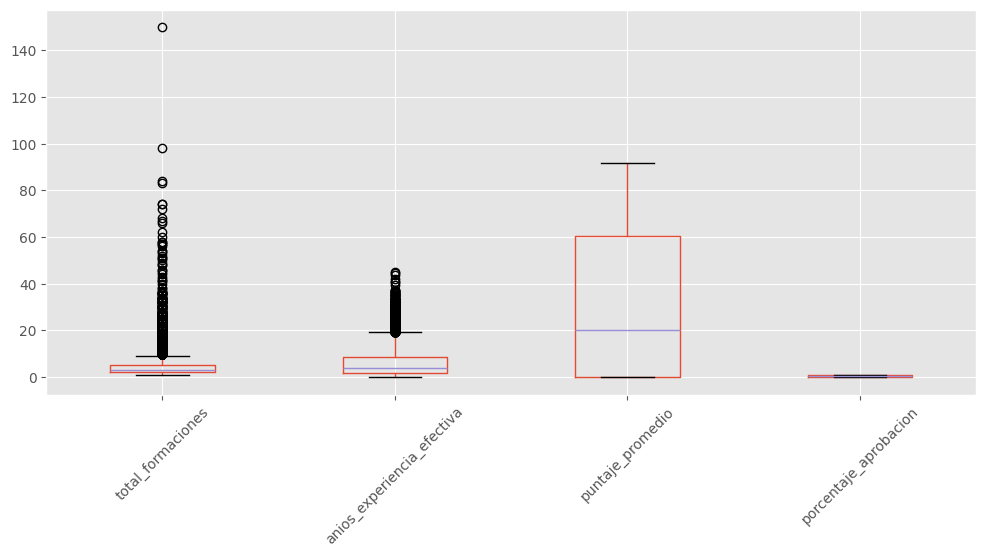

In [ ]:
variables = [
    "total_formaciones",
    "anios_experiencia_efectiva",
    "puntaje_promedio",
    "porcentaje_aprobacion"
]

abt[variables].boxplot(figsize=(12,5))
plt.xticks(rotation=45)
plt.show()

##8.9 Correlación entre variables numéricas

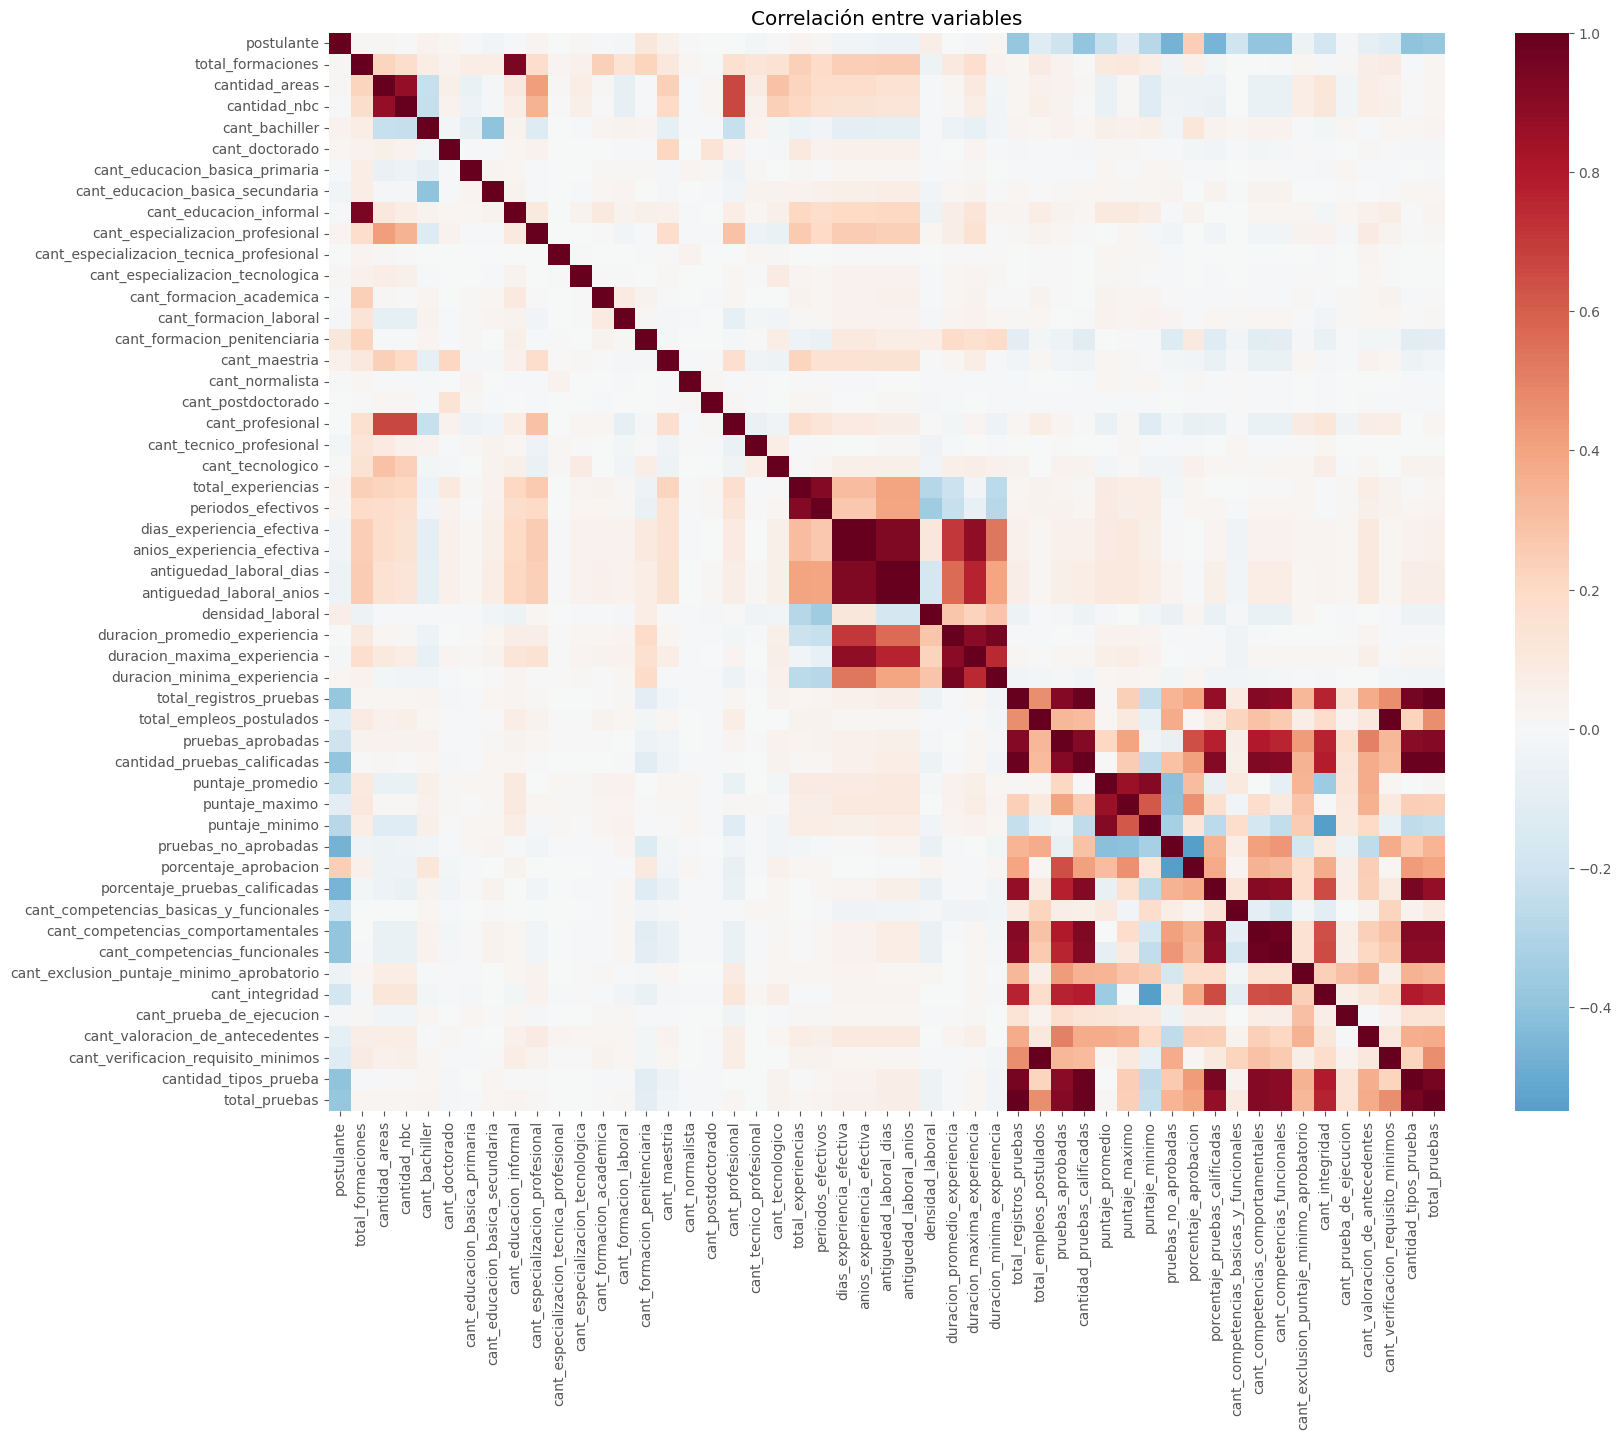

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = abt.select_dtypes(include="number").corr()

plt.figure(figsize=(18,14))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0
)
plt.title("Correlación entre variables")
plt.show()

##8.10 Distribución de la variable objetivo

<Axes: >

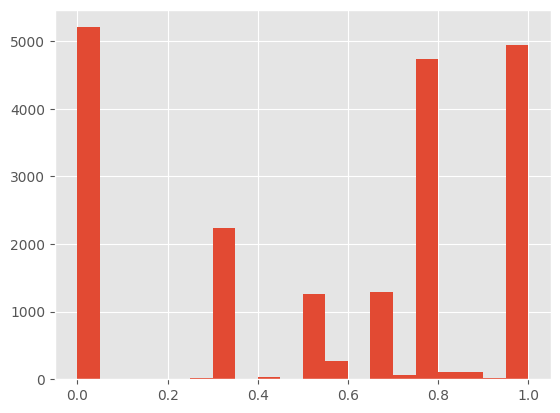

In [ ]:
abt["porcentaje_aprobacion"].hist(bins=20)

<Axes: >

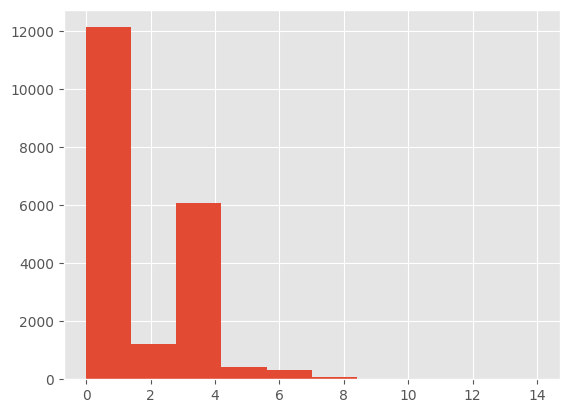

In [ ]:
abt["pruebas_aprobadas"].hist()

Conclusiones


La construcción de la Tabla Analítica Base (ABT) permitió integrar en una única estructura la información académica, la experiencia laboral y el historial de participación en procesos de selección de cada postulante. Una vez consolidada esta base, fue posible realizar un análisis exploratorio integral sobre la totalidad de las variables que conformarán el modelo predictivo.

El EDA evidenció que la ABT presenta una estructura consistente, con un registro único por postulante, ausencia de duplicados y una adecuada calidad de los datos para la mayoría de las variables. Asimismo, se identificó que los valores nulos se concentran únicamente en las variables relacionadas con puntajes de pruebas, situación esperada debido a que no todos los aspirantes alcanzaron etapas del proceso donde dichas evaluaciones generan una calificación numérica.

Desde la perspectiva descriptiva, el análisis permitió caracterizar el perfil general de los aspirantes. Se observó un predominio de postulantes con formación profesional y bachiller, una experiencia laboral mediana cercana a cuatro años, una alta continuidad en las trayectorias laborales reflejada en la densidad laboral y una participación relativamente limitada en procesos de selección, ya que la mayoría registra una sola postulación y pocas pruebas asociadas.

Las distribuciones de las variables revelaron la presencia de valores atípicos en indicadores como número de formaciones y años de experiencia, comportamiento esperado en datos administrativos que representan trayectorias laborales altamente heterogéneas. Igualmente, la matriz de correlación permitió identificar relaciones fuertes entre variables derivadas de una misma dimensión, especialmente aquellas asociadas con experiencia laboral y desempeño en pruebas, información que será considerada posteriormente para evitar redundancia y multicolinealidad durante el modelado.

En conjunto, el análisis exploratorio confirmó que la ABT constituye una representación consistente del perfil de los aspirantes y proporcionó un entendimiento profundo sobre la distribución, calidad y relaciones existentes entre las variables. Este conocimiento resulta fundamental antes de iniciar el desarrollo de modelos predictivos, ya que permite definir estrategias adecuadas de preparación de datos, selección de variables y construcción de características, incrementando la robustez y confiabilidad de las etapas posteriores del proyecto.
